In [3]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import joblib
from pathlib import Path

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, SVMSMOTE, SMOTENC

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
)

sys.path.append(str(Path("..").resolve()))

RANDOM_STATE = 42
PROCESSED_DIR = Path("../data/interim")
MODEL_DIR = Path("../models")
REPORT_DIR = Path("../reports")

In [4]:
# Load preprocessed data
X_train_pre = pd.read_csv(PROCESSED_DIR / "X_train_pre.csv", index_col=0)
X_val_pre   = pd.read_csv(PROCESSED_DIR / "X_val_pre.csv",   index_col=0)
y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv", index_col=0).squeeze()
y_val   = pd.read_csv(PROCESSED_DIR / "y_val.csv",   index_col=0).squeeze()

# Load base feature_transformer cho các phương pháp thông thường (SMOTE, Weighted...)
feature_transformer = joblib.load(MODEL_DIR / "feature_transformer.joblib")

print(f"Train: {X_train_pre.shape} | Val: {X_val_pre.shape}")

Train: (112560, 31) | Val: (28140, 31)


In [5]:
numeric_cols = X_train_pre.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train_pre.select_dtypes(exclude=np.number).columns.tolist()

# 1. Tầng Imputation: Chỉ điền giá trị thiếu (xóa NaN), chưa biến đổi gì thêm
imputer_ct = ColumnTransformer(
    transformers=[
        ("num_imp", SimpleImputer(strategy="median"), numeric_cols),
        ("cat_imp", SimpleImputer(strategy="constant", fill_value="Unknown"), categorical_cols),
    ],
    remainder="passthrough"
)

# Sau khi qua imputer_ct, dữ liệu trở thành numpy array, các cột numerical nằm trước, categorical nằm sau.
# Do đó ta cần tính toán lại index của các biến categorical cho SMOTENC.
new_cat_indices = list(range(len(numeric_cols), len(numeric_cols) + len(categorical_cols)))
print(f"Các chỉ mục cột Categorical dành cho SMOTENC: {new_cat_indices}")

# 2. Tầng Transformation: Chạy sau khi SMOTENC đã sinh thêm mẫu
transform_ct = ColumnTransformer(
    transformers=[
        ("num_scale", StandardScaler(), list(range(len(numeric_cols)))),
        ("cat_ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), new_cat_indices),
    ],
    remainder="drop"
)

Các chỉ mục cột Categorical dành cho SMOTENC: [27, 28, 29, 30]


In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.9, colsample_bytree=0.9, eval_metric="logloss", tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1)
}

def get_class_weight_model(model):
    # Clone model and set class_weight to balanced (except XGBoost which uses scale_pos_weight)
    m_clone = clone(model)
    if isinstance(m_clone, XGBClassifier):
        m_clone.set_params(scale_pos_weight=4)
    else:
        m_clone.set_params(class_weight="balanced")
    return m_clone

In [7]:
def evaluate_model(model_name, strategy_name, model, X_val, y_val):
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    
    metrics = {
        "model": model_name,
        "strategy": strategy_name,
        "accuracy": accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val, y_proba),
    }
    return metrics

results = []

for model_name, base_model in models.items():
    print(f"\n--- Evaluating {model_name} ---")
    
    pipelines = {
        "No Oversampling": ImbPipeline(steps=[
            ("feature_transformer", clone(feature_transformer)),
            ("classifier", clone(base_model)),
        ]),
        "Class Weight": ImbPipeline(steps=[
            ("feature_transformer", clone(feature_transformer)),
            ("classifier", get_class_weight_model(base_model)),
        ]),
        "SMOTE": ImbPipeline(steps=[
            ("feature_transformer", clone(feature_transformer)),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("classifier", clone(base_model)),
        ]),
        "BorderlineSMOTE": ImbPipeline(steps=[
            ("feature_transformer", clone(feature_transformer)),
            ("bsmote", BorderlineSMOTE(random_state=RANDOM_STATE)),
            ("classifier", clone(base_model)),
        ]),
        "SVMSMOTE": ImbPipeline(steps=[
            ("feature_transformer", clone(feature_transformer)),
            ("svmsmote", SVMSMOTE(random_state=RANDOM_STATE)),
            ("classifier", clone(base_model)),
        ]),
        "SMOTENC": ImbPipeline(steps=[
            ("imputer", imputer_ct),  # Điền giá trị thiếu trước
            ("smotenc", SMOTENC(categorical_features=new_cat_indices, random_state=RANDOM_STATE)), # Áp dụng SMOTENC
            ("transformer", transform_ct), # Áp dụng OHE và Standard Scaler
            ("classifier", clone(base_model)),
        ])
    }
    
    for strategy_name, pipeline in pipelines.items():
        print(f"Training: {strategy_name}...")
        pipeline.fit(X_train_pre, y_train)
        
        metrics = evaluate_model(model_name, strategy_name, pipeline, X_val_pre, y_val)
        results.append(metrics)
        print(f"{strategy_name}: F1={metrics['f1']:.4f} | Recall={metrics['recall']:.4f}")

print("\nAll experiments completed!")


--- Evaluating Logistic Regression ---
Training: No Oversampling...
No Oversampling: F1=0.8217 | Recall=0.8040
Training: Class Weight...
Class Weight: F1=0.7963 | Recall=0.9239
Training: SMOTE...
SMOTE: F1=0.7991 | Recall=0.9179
Training: BorderlineSMOTE...
BorderlineSMOTE: F1=0.7583 | Recall=0.9503
Training: SVMSMOTE...
SVMSMOTE: F1=0.7770 | Recall=0.9392
Training: SMOTENC...
SMOTENC: F1=0.8052 | Recall=0.9147

--- Evaluating Decision Tree ---
Training: No Oversampling...
No Oversampling: F1=0.8078 | Recall=0.7853
Training: Class Weight...
Class Weight: F1=0.7777 | Recall=0.9128
Training: SMOTE...
SMOTE: F1=0.7977 | Recall=0.8647
Training: BorderlineSMOTE...
BorderlineSMOTE: F1=0.7660 | Recall=0.8991
Training: SVMSMOTE...
SVMSMOTE: F1=0.7822 | Recall=0.9022
Training: SMOTENC...
SMOTENC: F1=0.7990 | Recall=0.8819

--- Evaluating Random Forest ---
Training: No Oversampling...
No Oversampling: F1=0.8188 | Recall=0.7923
Training: Class Weight...
Class Weight: F1=0.8103 | Recall=0.8928
Tr

In [8]:
results_df = pd.DataFrame(results).sort_values(by=["f1", "roc_auc"], ascending=False).reset_index(drop=True)

styled = results_df.style.format({
    "accuracy": "{:.4f}", "precision": "{:.4f}",
    "recall": "{:.4f}", "f1": "{:.4f}", "roc_auc": "{:.4f}"
}).highlight_max(
    subset=["accuracy", "precision", "recall", "f1", "roc_auc"],
    color="lightgreen"
)

display(styled)

,model,strategy,accuracy,precision,recall,f1,roc_auc
0,XGBoost,No Oversampling,0.9388,0.8423,0.8160,0.8289,0.9735
1,XGBoost,SMOTE,0.9362,0.8087,0.8498,0.8287,0.9730
2,XGBoost,SMOTENC,0.9349,0.7977,0.8598,0.8276,0.9733
3,Random Forest,SMOTE,0.9324,0.7866,0.8621,0.8226,0.9712
4,XGBoost,BorderlineSMOTE,0.9306,0.7682,0.8848,0.8224,0.9722
5,Random Forest,SMOTENC,0.9314,0.7778,0.8715,0.8220,0.9712
6,Logistic Regression,No Oversampling,0.9366,0.8402,0.8040,0.8217,0.9726
7,XGBoost,SVMSMOTE,0.9282,0.7543,0.8969,0.8194,0.9726
8,Random Forest,No Oversampling,0.9363,0.8471,0.7923,0.8188,0.9714
9,Random Forest,BorderlineSMOTE,0.9270,0.7582,0.8783,0.8139,0.9699


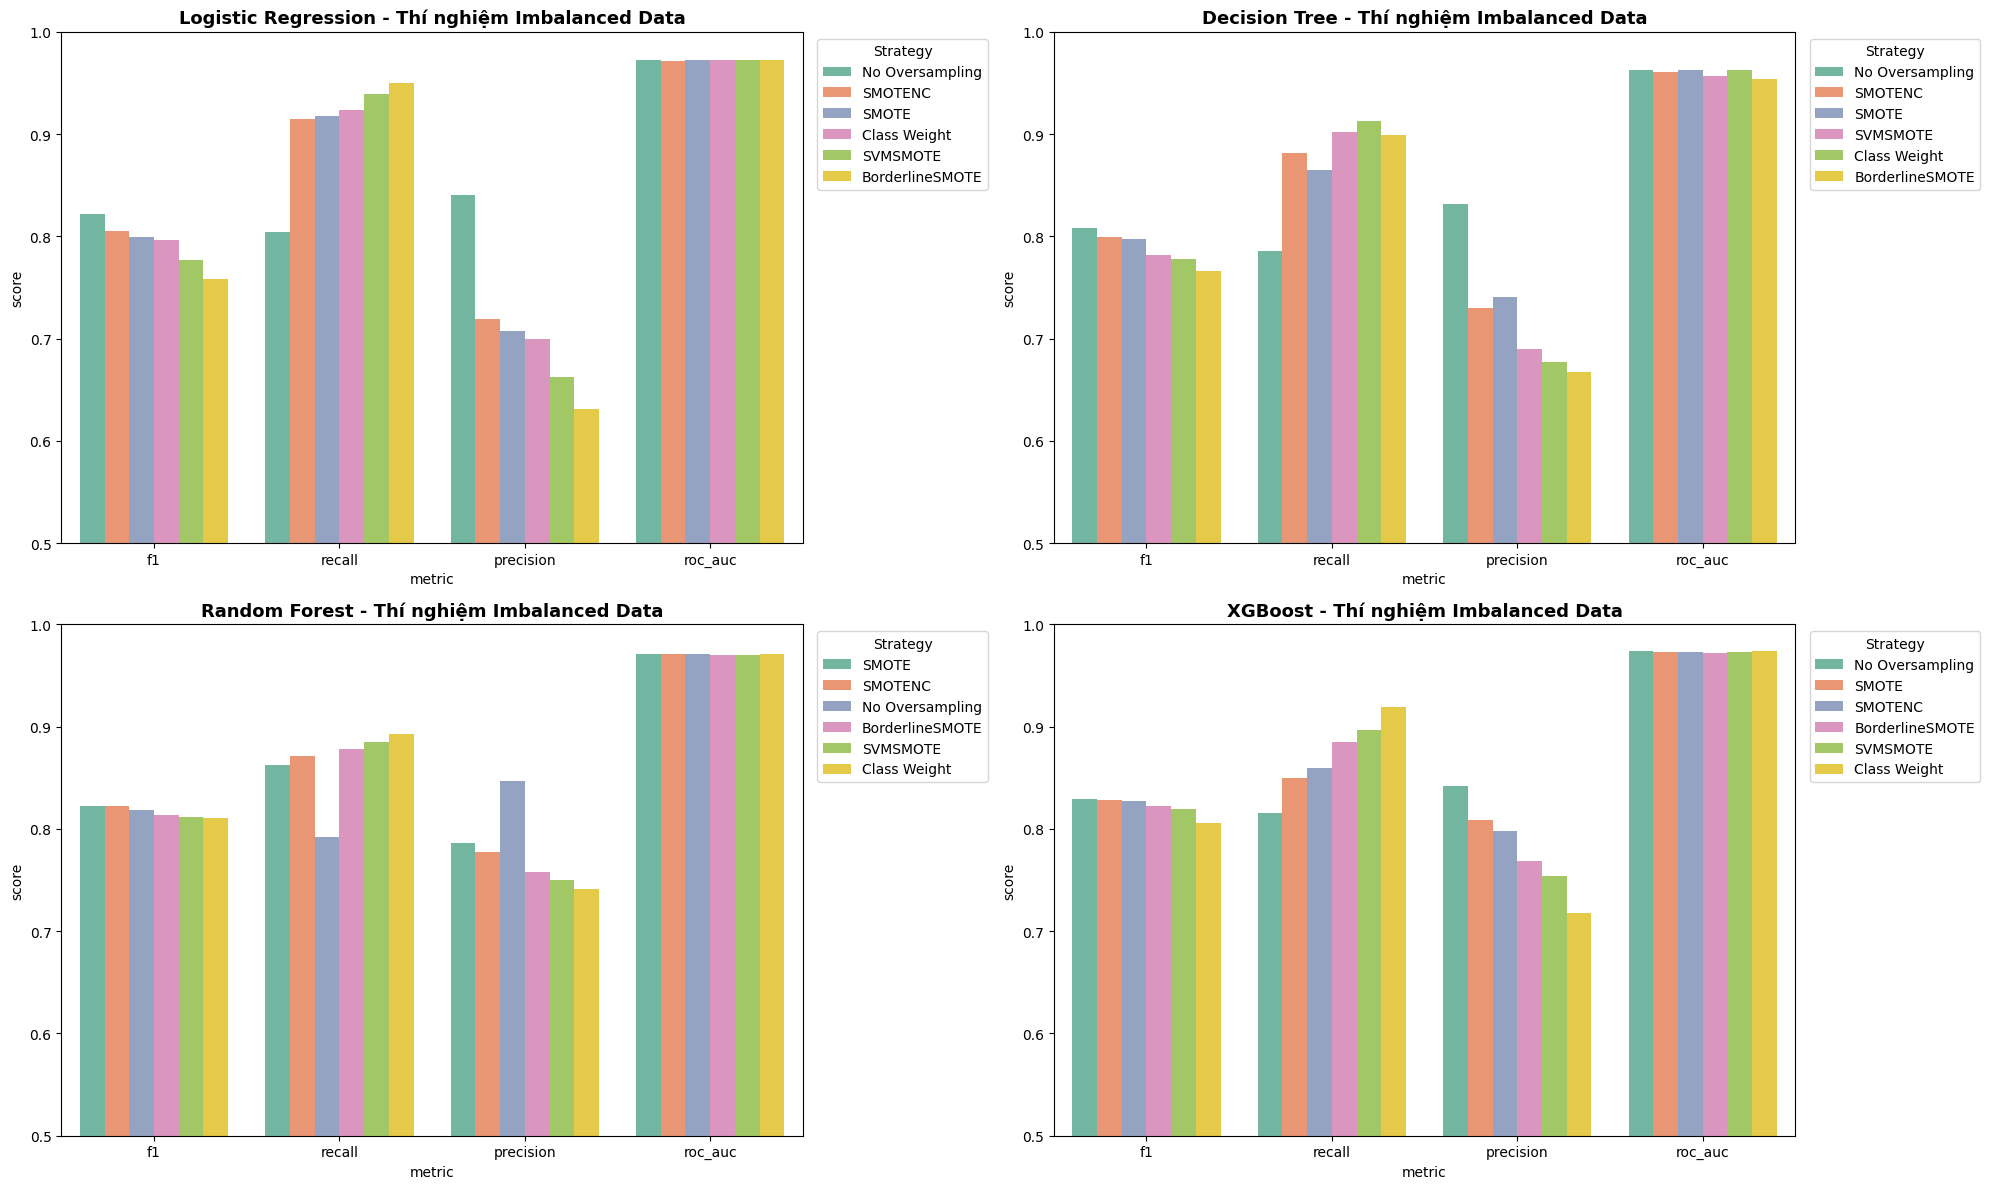

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

for idx, model_name in enumerate(models.keys()):
    ax = axes[idx]
    df_subset = results_df[results_df["model"] == model_name]
    
    plot_df = df_subset.melt(
        id_vars="strategy", 
        value_vars=["f1", "recall", "precision", "roc_auc"], 
        var_name="metric", 
        value_name="score"
    )
    
    sns.barplot(data=plot_df, x="metric", y="score", hue="strategy", palette="Set2", ax=ax)
    ax.set_ylim(0.5, 1.0)
    ax.set_title(f"{model_name} - Thí nghiệm Imbalanced Data", fontsize=13, fontweight="bold")
    ax.legend(title="Strategy", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.savefig(REPORT_DIR / "imbalance_experiment_comparison.png", bbox_inches="tight", dpi=150)
plt.show()